# Week 2 — RSI Mean Reversion (exploration)

Step-by-step walkthrough of the RSI(14) mean-reversion strategy on a single liquid stock. The cleaned-up version lives in `strategy.py`.

**Hypothesis:** RSI(14) < 30 → oversold → buy. RSI(14) > 70 → overbought → exit.

**Methodology guardrails:** Wilder's RSI, no parameter tuning, 5 bps per side cost, 1-day signal lag, benchmark = buy & hold.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from strategy import (
    fetch_prices,
    rsi_wilder,
    generate_positions,
    backtest,
    compute_metrics,
    plot_results,
)

pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load data

In [2]:
TICKER = 'AAPL'
START = '2010-01-01'
END = '2024-12-31'

prices = fetch_prices(TICKER, START, END)
print(f'Rows: {len(prices)}  Range: {prices.index.min().date()} → {prices.index.max().date()}')
prices.head()

Rows: 3773  Range: 2010-01-04 → 2024-12-30


Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,6.3891,6.4211,6.3577,6.4065,493729600
2010-01-05,6.4241,6.4538,6.3837,6.4176,601904800
2010-01-06,6.4176,6.4430,6.3089,6.3155,552160000
2010-01-07,6.3388,6.3463,6.2580,6.3038,477131200
2010-01-08,6.2954,6.3463,6.2583,6.3457,447610800


## 2. Compute RSI and inspect distribution

Sanity check: an RSI calculated correctly should be bounded [0, 100] with most observations clustered around 40–60.

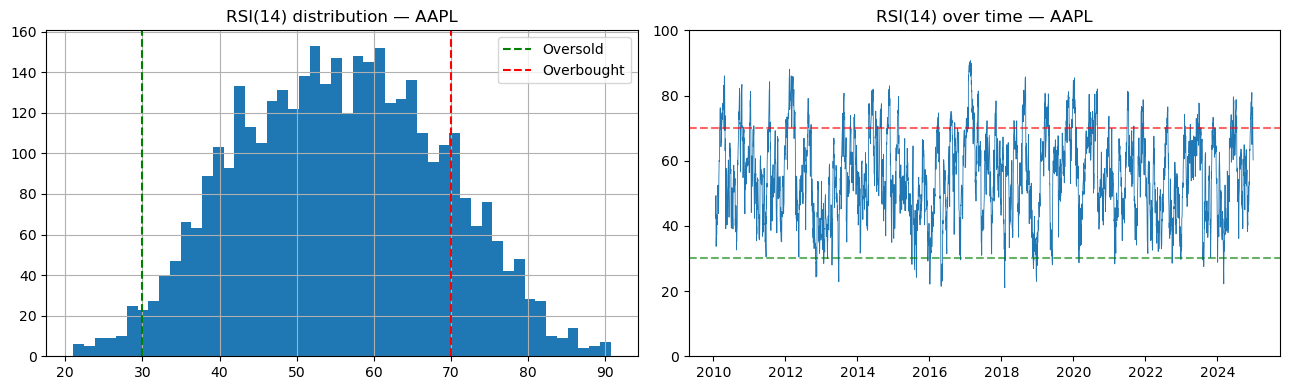

Days below 30: 75 | 1.99% of days
Days above 70: 564 | 14.95% of days


In [3]:
rsi = rsi_wilder(prices['Close'], period=14)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
rsi.hist(bins=50, ax=ax1)
ax1.axvline(30, color='green', linestyle='--', label='Oversold')
ax1.axvline(70, color='red', linestyle='--', label='Overbought')
ax1.set_title(f'RSI(14) distribution — {TICKER}')
ax1.legend()

ax2.plot(rsi.index, rsi, linewidth=0.6)
ax2.axhline(30, color='green', linestyle='--', alpha=0.6)
ax2.axhline(70, color='red', linestyle='--', alpha=0.6)
ax2.set_title(f'RSI(14) over time — {TICKER}')
ax2.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print('Days below 30:', (rsi < 30).sum(), '|', f'{(rsi < 30).mean():.2%} of days')
print('Days above 70:', (rsi > 70).sum(), '|', f'{(rsi > 70).mean():.2%} of days')

## 3. Generate signals

Confirm the entry/exit logic by spot-checking a few trades.

In [4]:
position = generate_positions(rsi, oversold=30, overbought=70)
n_entries = ((position.diff() == 1)).sum()
n_exits = ((position.diff() == -1)).sum()
print(f'Entries: {n_entries}  Exits: {n_exits}  Time in market: {position.mean():.2%}')

# Look at the first few entries to sanity-check
entry_dates = position.index[position.diff() == 1][:5]
for d in entry_dates:
    i = position.index.get_loc(d)
    print(f'{d.date()}  RSI(prev) = {rsi.iloc[i-1]:.1f}')

Entries: 12  Exits: 12  Time in market: 29.39%
2012-11-05  RSI(prev) = 29.7
2015-07-10  RSI(prev) = 28.2
2016-04-28  RSI(prev) = 26.6
2016-11-15  RSI(prev) = 29.6
2018-02-05  RSI(prev) = 24.8


## 4. Run the backtest

In [5]:
result = backtest(prices, position, cost_bps=5.0)
result['rsi'] = rsi

metrics = compute_metrics(result)
pd.Series(metrics)

total_return         1.4504
benchmark_return    38.1165
excess_return      -36.6660
sharpe               0.4289
benchmark_sharpe     1.0187
max_drawdown        -0.3771
calmar               3.8464
n_trades            12.0000
win_rate             0.8333
avg_trade_return     0.0864
time_in_market       0.2939
dtype: float64

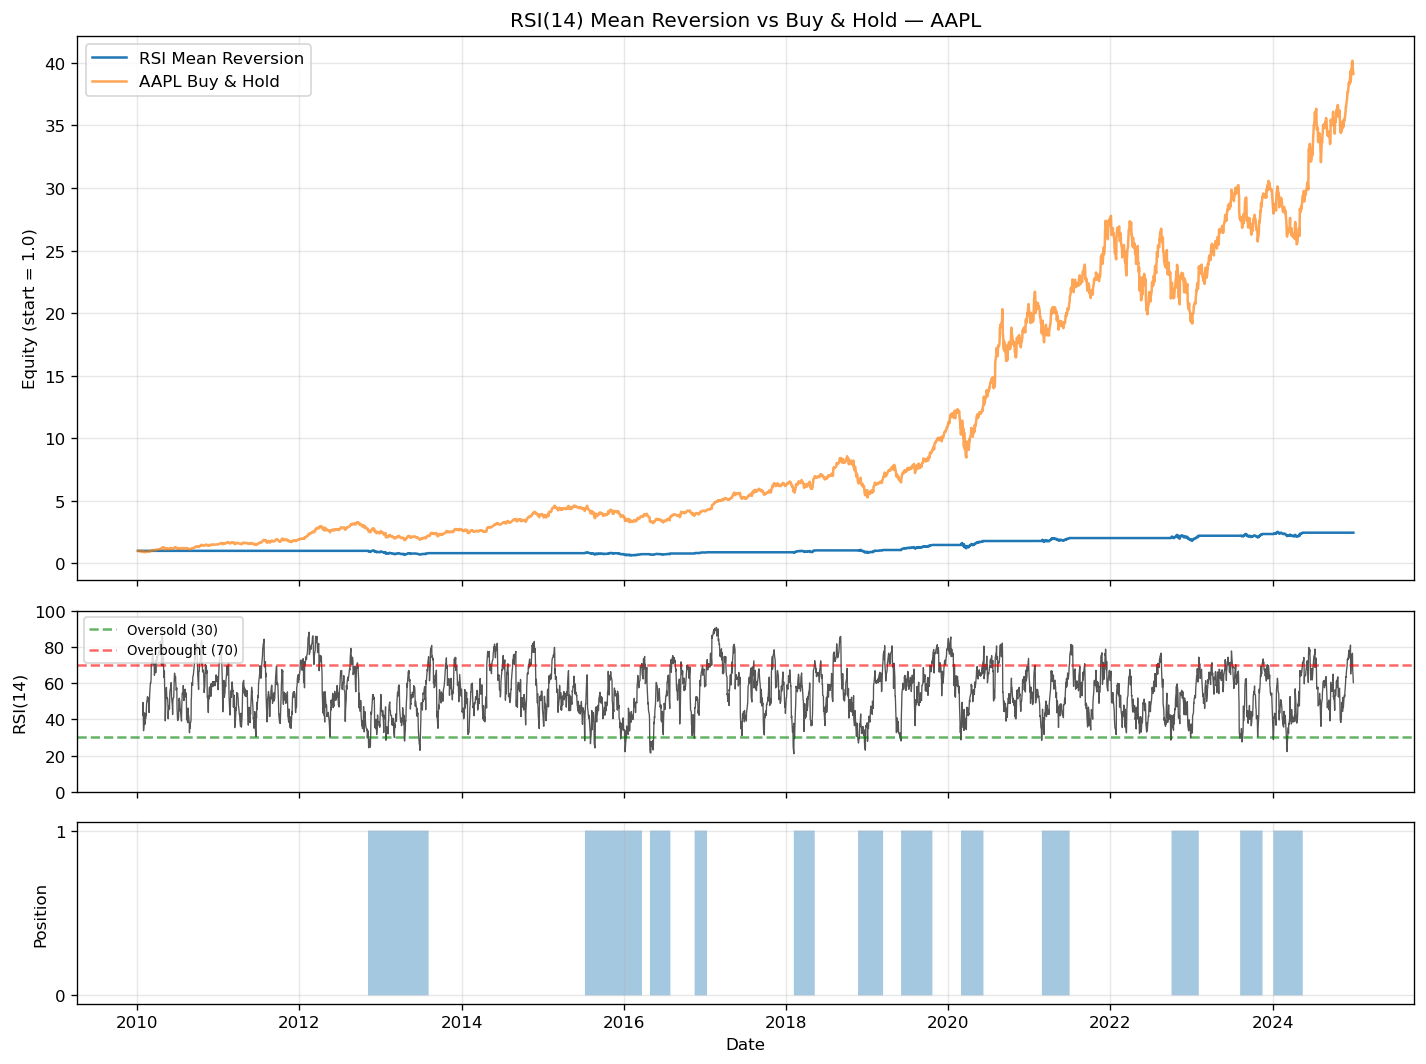

In [10]:
plot_results(result, rsi, TICKER, out_path='equity_curve.png')
from IPython.display import Image
Image('equity_curve.png')

## 5. Robustness — does it survive on other names?

Run on a small basket. If the result only holds on AAPL, we've over-fit to one stock's history.

In [11]:
basket = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'XOM', 'KO', 'SPY']
rows = []
for tkr in basket:
    try:
        p = fetch_prices(tkr, START, END)
        r = rsi_wilder(p['Close'])
        pos = generate_positions(r)
        res = backtest(p, pos)
        m = compute_metrics(res)
        rows.append({'ticker': tkr, **m})
    except Exception as e:
        print(f'{tkr}: {e}')

robustness = pd.DataFrame(rows).set_index('ticker')
robustness[['total_return', 'benchmark_return', 'excess_return', 'sharpe', 'max_drawdown', 'n_trades', 'win_rate']]

,total_return,benchmark_return,excess_return,sharpe,max_drawdown,n_trades,win_rate
ticker,,,,,,,
AAPL,1.4504,38.1165,-36.6660,0.4289,-0.3771,12,0.8333
MSFT,2.1138,17.2325,-15.1187,0.5999,-0.3177,11,0.8182
GOOGL,2.0424,11.2372,-9.1948,0.4989,-0.4363,13,0.9231
JPM,1.8321,7.2081,-5.3760,0.4307,-0.3877,15,0.8667
XOM,1.7662,1.6930,0.0732,0.4577,-0.5793,16,0.7500
KO,0.7817,2.4557,-1.6740,0.3853,-0.3569,14,0.7857
SPY,1.7887,5.8377,-4.0490,0.5920,-0.2834,14,0.9286


## 6. Parameter sensitivity

Vary the entry/exit thresholds. A robust effect should appear across nearby parameter choices, not just at one sweet spot.

In [12]:
sensitivity = []
for os_thresh in [20, 25, 30, 35]:
    for ob_thresh in [60, 65, 70, 75, 80]:
        pos = generate_positions(rsi, os_thresh, ob_thresh)
        res = backtest(prices, pos)
        m = compute_metrics(res)
        sensitivity.append({
            'oversold': os_thresh,
            'overbought': ob_thresh,
            'total_return': m['total_return'],
            'sharpe': m['sharpe'],
            'n_trades': m['n_trades'],
        })

pd.DataFrame(sensitivity).pivot(index='oversold', columns='overbought', values='sharpe').round(2)

overbought,60,65,70,75,80
oversold,,,,,
20,0.0000,0.0000,0.0000,0.0000,0.0000
25,0.3600,0.4600,0.3200,0.4200,0.6500
30,0.3200,0.3300,0.4300,0.6200,0.7400
35,0.4300,0.5100,0.6300,0.8800,0.9300


## 7. Conclusions

_Fill this in once results are in — the writeup in `README.md` is the polished version._

Questions to answer:
- Did the strategy beat buy & hold on a risk-adjusted basis?
- Was the result consistent across the basket, or driven by one or two names?
- Did the Sharpe survive the 2020 COVID dump and 2022 drawdown, or did it collapse?
- How sensitive is the result to threshold choice?